# Matplotlib: Advanced and Real-World

The first three notebooks covered the fundamentals (Figure/Axes, the two APIs), the seven core plot types, and customization (colors, ticks, annotations, themes). This notebook is where everything comes together for the kinds of figures you actually need to ship: dashboards with non-uniform layouts, charts with two different y-scales, heatmaps for correlation and confusion matrices, publication-quality saves, and a glance at seaborn (matplotlib's higher-level sibling).

**What you'll learn:**
1. Non-uniform layouts with `GridSpec`
2. Twin axes — two y-scales on a single chart
3. Heatmaps for any 2D data
4. Correlation matrices (the diverging-colormap pattern)
5. Confusion matrices for classification
6. Publication-quality saves
7. seaborn — what it adds and when to reach for it
8. A complete multi-panel dashboard, end to end

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
np.random.seed(42)

## Complex Layouts with GridSpec

`plt.subplots(rows, cols)` is perfect when every panel in your figure is the same size. It breaks down the moment you want a layout like "one big chart on top, three smaller ones below" — uniform grids can't express that.

**GridSpec** is the matplotlib tool for non-uniform layouts. You divide the figure into a virtual grid (say, 2 rows × 3 columns) and then place each axes by claiming one or more cells of that grid. A single axes can occupy a 1×1 cell, or a 2×3 block, or any rectangle in between.

The mental model:

1. Create the figure first with `plt.figure(...)`.
2. Define a `GridSpec(rows, cols, figure=fig)`.
3. Call `fig.add_subplot(gs[row_slice, col_slice])` once per panel, slicing into the grid like a NumPy array.

The slice notation is the key — `gs[0, :2]` means "row 0, columns 0 through 1" (a panel spanning two columns). The pattern is identical to NumPy 2D slicing.

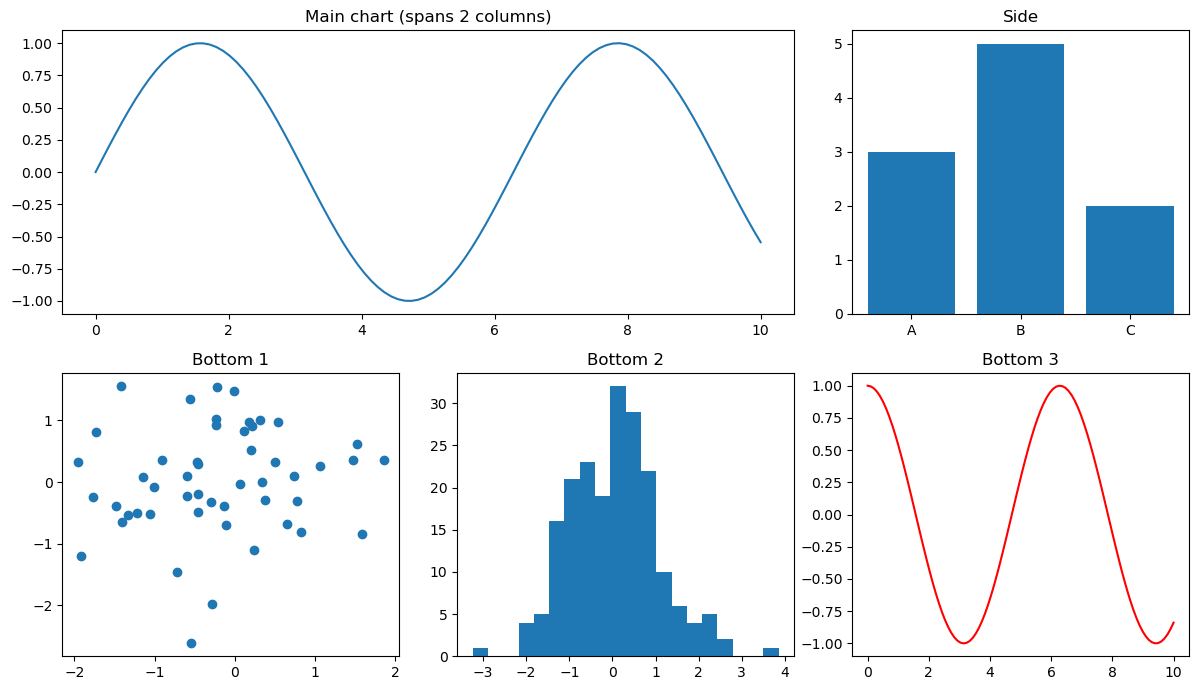

In [2]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(12, 7))
gs = GridSpec(2, 3, figure=fig)

# Top-left spans 2 columns (the big chart)
ax_main = fig.add_subplot(gs[0, :2])

# Top-right (smaller side panel)
ax_side = fig.add_subplot(gs[0, 2])

# Bottom row — three small charts
ax_b1 = fig.add_subplot(gs[1, 0])
ax_b2 = fig.add_subplot(gs[1, 1])
ax_b3 = fig.add_subplot(gs[1, 2])

# Fill in some content
x = np.linspace(0, 10, 100)
ax_main.plot(x, np.sin(x))
ax_main.set_title("Main chart (spans 2 columns)")

ax_side.bar(['A', 'B', 'C'], [3, 5, 2])
ax_side.set_title("Side")

ax_b1.scatter(np.random.randn(50), np.random.randn(50))
ax_b1.set_title("Bottom 1")

ax_b2.hist(np.random.randn(200), bins=20)
ax_b2.set_title("Bottom 2")

ax_b3.plot(x, np.cos(x), color='red')
ax_b3.set_title("Bottom 3")

plt.tight_layout()
plt.show()

**Reading the code:**

- `plt.figure(figsize=(12, 7))` creates the figure first, without any axes. With GridSpec you build the figure, decide on the grid, then place each axes by hand — the order matters because GridSpec needs to know which figure it belongs to.
- `GridSpec(2, 3, figure=fig)` divides the figure into 2 rows × 3 columns of virtual cells. Nothing is drawn yet; the grid only exists to tell axes where to live.
- `fig.add_subplot(gs[0, :2])` creates an axes that occupies row 0 and columns 0–1 (the first two cells of the top row). `:2` is a NumPy slice meaning "everything before index 2."
- `fig.add_subplot(gs[0, 2])` claims the remaining cell in the top row (row 0, column 2).
- The three bottom panels each claim one cell of row 1 (`gs[1, 0]`, `gs[1, 1]`, `gs[1, 2]`).
- `plt.tight_layout()` adjusts the spacing between the now-different-sized panels so titles don't collide with neighbors.

### GridSpec slicing cheat sheet

| Slice | What it claims |
|---|---|
| `gs[0, 0]` | Single cell, top-left |
| `gs[0, :]` | Entire top row |
| `gs[:, 0]` | Entire left column |
| `gs[1:, 1:]` | Bottom-right block (all rows from index 1, all columns from index 1) |
| `gs[0, :2]` | Row 0, columns 0–1 (two-cell wide panel) |
| `gs[:2, 0]` | Rows 0–1, column 0 (two-cell tall panel) |

If you can index a NumPy array, you can place a GridSpec axes.

## Twin Axes — Two y-Scales on One Chart

When you want to plot two quantities on the same chart but they live on completely different scales — temperature in degrees Celsius (0–35) and rainfall in millimeters (0–100), or a count and a percentage — neither variable will be readable if you force them onto the same y-axis. The variable with the larger range will dominate, and the smaller one will look like a flat line at the bottom.

**Twin axes** solve this by drawing the two variables against two separate y-axes — one on the left, one on the right. They share the same x-axis (so the horizontal positions line up) but each has its own scale.

The pattern:

1. Create the figure and the first axes with `plt.subplots(...)` — call it `ax1`.
2. Plot the first variable on `ax1` and label the left y-axis.
3. Call `ax2 = ax1.twinx()` to create a second axes that shares x with `ax1` but has its own y on the right.
4. Plot the second variable on `ax2` and label the right y-axis.

Match the axis color to the data color (red ticks on the temperature axis, blue ticks on the rainfall axis) so the reader knows immediately which curve reads off which scale.

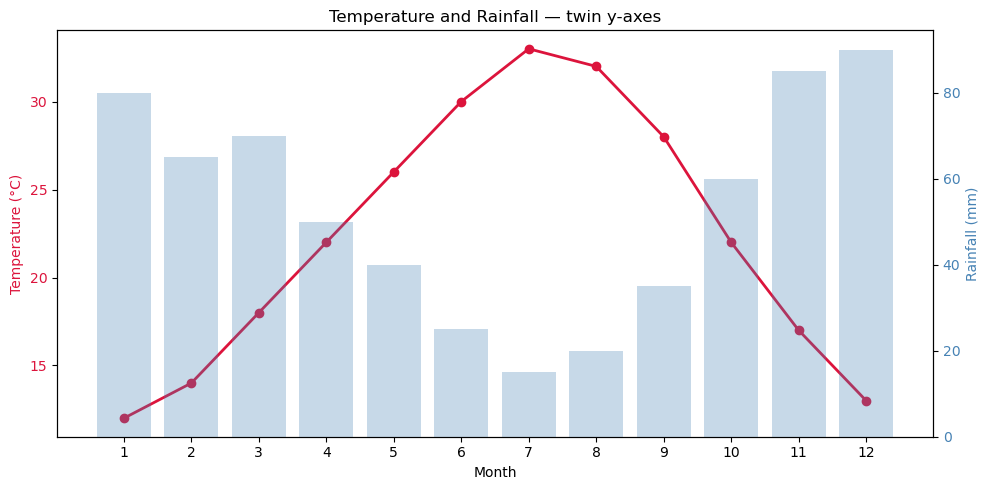

In [3]:
# Same x, two y-axes
months = np.arange(1, 13)
temperature = [12, 14, 18, 22, 26, 30, 33, 32, 28, 22, 17, 13]
rainfall    = [80, 65, 70, 50, 40, 25, 15, 20, 35, 60, 85, 90]

fig, ax1 = plt.subplots(figsize=(10, 5))

# First axis: temperature on the left, in red
color1 = 'crimson'
ax1.plot(months, temperature, color=color1, marker='o', linewidth=2, label='Temperature')
ax1.set_xlabel("Month")
ax1.set_ylabel("Temperature (°C)", color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Twin axes: rainfall on the right, in blue
ax2 = ax1.twinx()
color2 = 'steelblue'
ax2.bar(months, rainfall, color=color2, alpha=0.3, label='Rainfall')
ax2.set_ylabel("Rainfall (mm)", color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

ax1.set_title("Temperature and Rainfall — twin y-axes")
ax1.set_xticks(months)
plt.tight_layout()
plt.show()

**Reading the code:**

- `fig, ax1 = plt.subplots(figsize=(10, 5))` creates the figure and the first (left) axes. The naming convention `ax1` (rather than just `ax`) makes it clear there's going to be a second axes.
- `ax1.plot(...)` draws temperature with crimson markers and labels the left y-axis the same color. The `tick_params(axis='y', labelcolor=color1)` call colors the tick numbers too, so the entire left side reads as "this is the temperature axis."
- `ax2 = ax1.twinx()` is the key call. It creates a new axes occupying the same screen rectangle as `ax1`, sharing its x-axis but with its own independent y-axis on the right. The name `twinx` means "twin sharing x." (There's also `twiny` for sharing y instead, which is rarer.)
- `ax2.bar(...)` draws rainfall as semi-transparent bars (`alpha=0.3`) so they sit behind the temperature line without obscuring it. Mixing chart types — line for one variable, bars for the other — also helps the reader keep the two series straight.
- The two y-labels and their tick colors match their data colors. This single visual cue is what makes the chart readable at all; without it the reader has to guess which axis goes with which curve.

## Heatmaps — Visualizing Matrices

A **heatmap** is a 2D grid where each cell's color encodes a numeric value. Use it whenever you have data that's naturally arranged in a matrix — values for every (row, column) combination — and you want the reader to spot patterns at a glance. Common uses:

- **Activity matrices** — metrics broken down by two categories (region × month, server × hour of day)
- **Correlation matrices** — how strongly each pair of variables moves together
- **Confusion matrices** — what a classifier got right and what it confused

Matplotlib's `imshow` is the function that draws a heatmap. The arguments you'll touch most:

- `cmap=` — the colormap (sequential like `'viridis'` for general data, diverging like `'RdBu_r'` for data centered on zero).
- `aspect='auto'` — lets the cells stretch to fill the axes box instead of staying square.
- `vmin=`, `vmax=` — fix the value range the colormap covers. Important for correlation matrices, where you want `vmin=-1, vmax=1` so the midpoint of the colormap lines up with zero correlation.

To annotate each cell with its numeric value, loop over the grid and call `ax.text` once per cell. The conventional trick is to switch the text color (black on light backgrounds, white on dark ones) using a threshold.

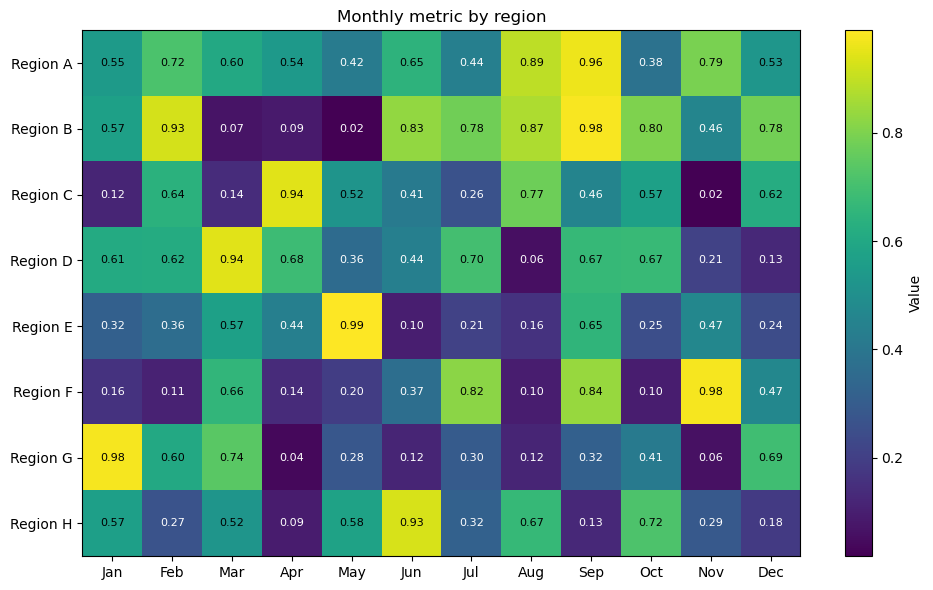

In [4]:
# Heatmap from a 2D array
np.random.seed(0)
data = np.random.rand(8, 12)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(data, cmap='viridis', aspect='auto')

# Add colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Value")

# Custom tick labels
ax.set_xticks(range(12))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.set_yticks(range(8))
ax.set_yticklabels(['Region ' + chr(65 + i) for i in range(8)])

# Annotate each cell with its value
for i in range(8):
    for j in range(12):
        ax.text(j, i, f'{data[i, j]:.2f}', ha='center', va='center',
                color='white' if data[i, j] < 0.5 else 'black', fontsize=8)

ax.set_title("Monthly metric by region")
plt.tight_layout()
plt.show()

**Reading the code:**

- `np.random.rand(8, 12)` produces an 8×12 array of values uniformly distributed between 0 and 1. Eight rows for the regions, twelve columns for the months.
- `ax.imshow(data, cmap='viridis', aspect='auto')` is the actual heatmap call. `imshow` is the same function used to display images (since a heatmap is just an "image" of numeric values). `aspect='auto'` lets the cells stretch — without it, `imshow` keeps pixels square and the result would be a tall narrow strip.
- `fig.colorbar(im, ax=ax)` adds the color-to-value legend on the right. The colorbar needs the return value of `imshow` (here captured as `im`) so it knows the value range and colormap.
- The custom tick labels use two patterns:
  - `ax.set_xticks(range(12))` followed by `ax.set_xticklabels([...])` is the standard two-step for replacing numeric ticks with text.
  - `chr(65 + i)` is a trick: `chr(65)` is `'A'`, `chr(66)` is `'B'`, etc. So the y-tick labels become `'Region A'`, `'Region B'`, ... `'Region H'`.
- The nested `for i in range(8): for j in range(12):` loop writes the numeric value inside each cell.
  - `ax.text(j, i, ...)` — note the argument order: x-coordinate first, then y-coordinate. In `imshow`, column index `j` corresponds to x and row index `i` corresponds to y.
  - `color='white' if data[i, j] < 0.5 else 'black'` picks contrasting text. Dark cells (low values in viridis are dark purple) get white text; light cells (high values are yellow) get black text. The threshold `0.5` works because our data spans 0–1 and viridis transitions in roughly the middle.

### A correlation matrix with a diverging colormap

A **correlation matrix** is a square heatmap where each cell `[i, j]` holds the correlation between variable `i` and variable `j`. The value range is always −1 to +1, and the meaningful midpoint is zero (no correlation). This is a textbook case for a *diverging* colormap with explicit `vmin` and `vmax`:

- `cmap='RdBu_r'` — red for positive correlations, blue for negative, white in the middle.
- `vmin=-1, vmax=1` — pin the colormap so white is *exactly* at zero, not at the empirical midpoint of the data.

Without those settings, matplotlib auto-scales the colormap to fit your data's range, and the visual midpoint won't match zero correlation.

Correlation matrix:
      A     B     C     D     E
A  1.00  0.85 -0.10 -0.79 -0.10
B  0.85  1.00  0.02 -0.69 -0.10
C -0.10  0.02  1.00  0.07  0.05
D -0.79 -0.69  0.07  1.00  0.02
E -0.10 -0.10  0.05  0.02  1.00


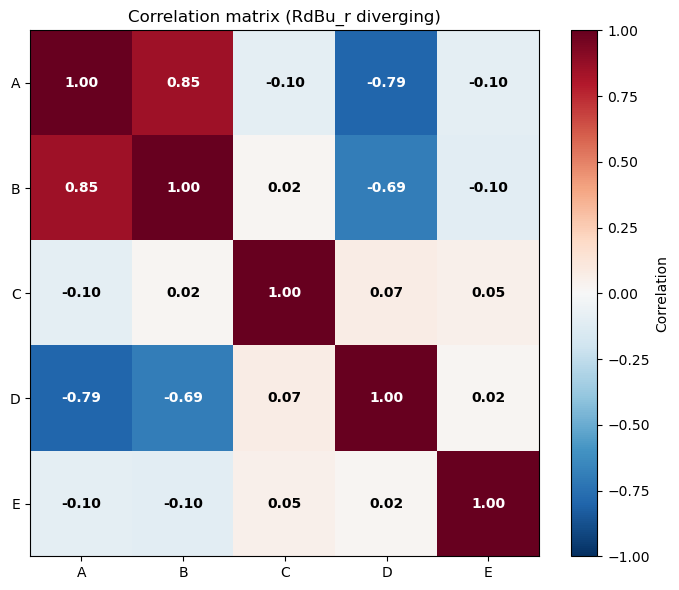

In [5]:
# Correlation matrix heatmap — common in EDA
np.random.seed(0)
df = pd.DataFrame(np.random.randn(100, 5), columns=['A', 'B', 'C', 'D', 'E'])

# Inject some real correlations
df['B'] =  df['A'] * 0.8 + np.random.randn(100) * 0.5
df['D'] = -df['A'] * 0.6 + np.random.randn(100) * 0.5

corr = df.corr()
print("Correlation matrix:")
print(corr.round(2))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
fig.colorbar(im, ax=ax, label='Correlation')

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns)
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)

# Annotate cells
for i in range(len(corr)):
    for j in range(len(corr)):
        val = corr.iloc[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                color='white' if abs(val) > 0.5 else 'black', fontweight='bold')

ax.set_title("Correlation matrix (RdBu_r diverging)")
plt.tight_layout()
plt.show()

**Reading the code:**

- `np.random.randn(100, 5)` builds a 100-row, 5-column array of standard normal samples. Each column will be one of the five variables A, B, C, D, E.
- The two injected correlations are the interesting part:
  - `df['B'] = df['A'] * 0.8 + noise` makes B strongly *positively* correlated with A.
  - `df['D'] = -df['A'] * 0.6 + noise` makes D *negatively* correlated with A (and, transitively, with B).
- `df.corr()` is pandas' method for the pairwise correlation matrix. It returns a DataFrame with the same columns and index, where cell `[i, j]` is the Pearson correlation between columns `i` and `j`. The diagonal is always 1 (every variable is perfectly correlated with itself).
- `ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, ...)` draws the heatmap. `'RdBu_r'` is the reverse of `'RdBu'` — `_r` means "reversed." The reverse maps high values to red (positive correlation feels "warm") and low values to blue (negative correlation feels "cool"), which matches the convention readers expect.
- The annotation threshold uses `abs(val) > 0.5` rather than `val > 0.5`. Strong correlations in either direction (positive or negative) sit on dark colors (deep red or deep blue), so they all want white text.

## Confusion Matrix — The ML Essential

A **confusion matrix** is a special heatmap used to evaluate classification models. Rows represent the true class, columns represent the predicted class, and each cell `[i, j]` is the count of times the model predicted class `j` when the truth was class `i`. The diagonal (`[0,0]`, `[1,1]`, `[2,2]`, …) is the model's correct predictions; off-diagonal cells are mistakes.

Reading a confusion matrix is a four-step habit:

1. Look at the diagonal. Strong diagonal = good model; weak diagonal = bad.
2. Look at off-diagonal hot spots. They tell you *which* classes the model confuses with which. "Confused dogs for cats" is a specific failure mode you can act on; "low overall accuracy" is not.
3. Sum the diagonal and divide by the total — that's the accuracy.
4. Look at any row that's diagonally weak — that class is the one the model struggles with.

Visually, the convention is a sequential colormap (commonly `'Blues'`) so that big numbers (the diagonal) appear dark and stand out. The pattern is otherwise identical to any other annotated heatmap.

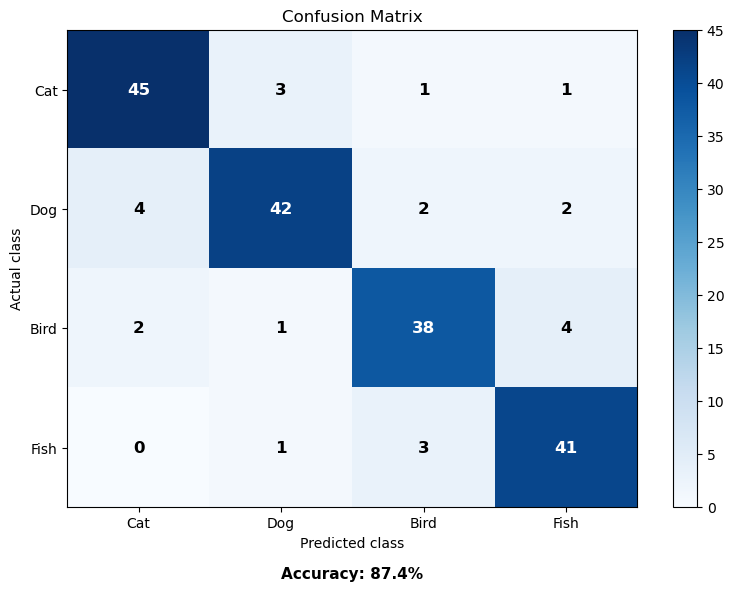

Accuracy: 87.4%


In [6]:
# Simulate a confusion matrix
# Rows = actual class, columns = predicted class
np.random.seed(0)

class_names = ['Cat', 'Dog', 'Bird', 'Fish']
n_classes = len(class_names)

# A realistic confusion matrix (high diagonal = good model)
cm = np.array([
    [45,  3,  1,  1],   # actual Cat
    [ 4, 42,  2,  2],   # actual Dog
    [ 2,  1, 38,  4],   # actual Bird
    [ 0,  1,  3, 41],   # actual Fish
])

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues', aspect='auto')
fig.colorbar(im, ax=ax)

ax.set_xticks(range(n_classes))
ax.set_yticks(range(n_classes))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted class")
ax.set_ylabel("Actual class")
ax.set_title("Confusion Matrix")

# Annotate cells
threshold = cm.max() / 2
for i in range(n_classes):
    for j in range(n_classes):
        color = "white" if cm[i, j] > threshold else "black"
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color=color, fontsize=12, fontweight='bold')

# Compute accuracy and put it below the chart
accuracy = np.trace(cm) / cm.sum()
ax.text(0.5, -0.15, f'Accuracy: {accuracy*100:.1f}%',
        transform=ax.transAxes, ha='center',
        fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()
print(f"Accuracy: {accuracy*100:.1f}%")

**Reading the code:**

- `cm = np.array([...])` is the hand-built confusion matrix. The high diagonal values (45, 42, 38, 41) and low off-diagonal values say this is a competent model — most predictions land on the right class.
- `ax.imshow(cm, cmap='Blues', aspect='auto')` uses the sequential `'Blues'` colormap. Higher counts → darker blue → the diagonal stands out visually.
- `ax.set_xlabel("Predicted class")` and `ax.set_ylabel("Actual class")` are essential. Without them the reader can't know which axis is which, and the matrix becomes meaningless — swapping the labels inverts your interpretation.
- `threshold = cm.max() / 2` picks the midpoint of the value range for the white-text cutoff. Cells with counts above the threshold sit on dark blue (white text wins); cells below sit on light blue (black text wins).
- `np.trace(cm)` is NumPy's sum-of-diagonal. For a confusion matrix that's "correct predictions." Dividing by `cm.sum()` (total predictions) gives accuracy.
- `ax.text(0.5, -0.15, ..., transform=ax.transAxes, ...)` places the accuracy text in *axes coordinates*. `(0.5, -0.15)` means "horizontally centered, 15% below the bottom of the plot." Using `transAxes` means the position is relative to the axes box, not to data values — useful when you want to pin text in a specific spot regardless of the data range.

## Publication-Quality Saves

Matplotlib's default save settings are tuned for quick exploration, not for final output. A few extra arguments to `fig.savefig` turn a screen-quality PNG into something that holds up in a paper, slide deck, or printed poster.

The arguments that matter:

- `dpi=` — resolution in dots per inch. Defaults to 100 (fine for a notebook preview). For slides, bump to 150. For print and conference posters, 300 is the standard.
- `bbox_inches='tight'` — trim off extra whitespace around the figure so it doesn't sit in a giant margin. Always worth using on saves intended for documents.
- `facecolor='white'` — force a solid white background. Useful for slides that have a dark theme but you want your chart on white.
- `transparent=True` — the opposite: make the background see-through. Use when pasting a chart over a colored slide.

A second habit for publication output is reducing visual weight: hide the top and right spines, bump up the line widths and font sizes to compensate for the smaller relative scale at which the chart will be viewed.

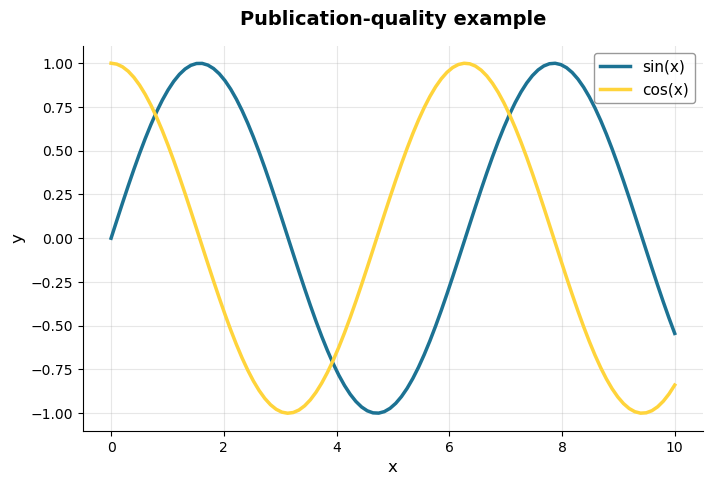

Saved in 3 formats at publication quality (300 dpi for PNG)


In [7]:
# Publication-ready figure
fig, ax = plt.subplots(figsize=(8, 5))

x = np.linspace(0, 10, 100)
ax.plot(x, np.sin(x), linewidth=2.5, color='#1C7293', label='sin(x)')
ax.plot(x, np.cos(x), linewidth=2.5, color='#FFD43B', label='cos(x)')

ax.set_title("Publication-quality example",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("y", fontsize=12)
ax.legend(fontsize=11, loc='best', frameon=True, edgecolor='gray')
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Save in multiple formats at high quality
fig.savefig('publication.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig('publication.pdf',           bbox_inches='tight', facecolor='white')
fig.savefig('publication.svg',           bbox_inches='tight')

plt.show()
print("Saved in 3 formats at publication quality (300 dpi for PNG)")

**Reading the code:**

- `linewidth=2.5` is heavier than the default 1.5. Thin lines disappear when a figure is scaled down for a slide deck or shrunk into a multi-panel paper figure; thicker lines survive.
- The colors `'#1C7293'` (a muted teal) and `'#FFD43B'` (gold) are picked to be both distinguishable and printable. Default `'C0'`/`'C1'` look fine on screen, but printed at A4 size, brand-specific hex codes look more deliberate.
- `ax.set_title(..., pad=15)` adds 15 points of vertical padding between the title and the plot area. Crowded titles read worse than spaced ones, especially in print.
- `legend(..., frameon=True, edgecolor='gray')` keeps the legend's border but switches the default black border to gray — a small reduction in visual weight.
- The three `savefig` calls write the same figure in three formats. `dpi=300` only matters for the raster format (PNG); PDF and SVG are vector and stay sharp at any zoom level regardless of `dpi`.

### Save settings cheat sheet

| Use case | Settings |
|---|---|
| Slides | `dpi=150`, `.png`, opaque background |
| Academic papers | `dpi=300`, `.pdf`, `bbox_inches='tight'` |
| Web | `dpi=100`, `.png` or `.svg` |
| Print and posters | `dpi=300+`, `.pdf` or `.tiff`, large figsize like `(20, 15)` |

## seaborn — Matplotlib's Higher-Level Sibling

**seaborn** is a separate library built on top of matplotlib. It exposes a smaller, more opinionated set of functions specifically for statistical plots, and the defaults are much more attractive than matplotlib's. You import it like this:

```python
import seaborn as sns
```

The convention `sns` is a nod to a character from *The West Wing* — Samuel Norman Seaborn — and is so standard you should use it even though the name doesn't match the library at all.

What seaborn adds:

- **Statistical plots in one line** — box plots, violin plots, regression scatters, and pair plots that would take ten lines of matplotlib.
- **A `hue=` argument** that colors any plot by a categorical column. The matplotlib equivalent is a loop over the categories with manual color handling.
- **Built-in themes** that style every chart at once. `sns.set_theme(style='whitegrid')` and similar calls switch the global look.
- **Built-in datasets** for practice — `sns.load_dataset('tips')`, `'iris'`, `'penguins'`, and others.

What seaborn does *not* replace: complex custom layouts, fine-tuned axis control, ML-specific charts like confusion matrices. The professional workflow uses both — seaborn for the quick exploratory pass, matplotlib for the final polish.

In [8]:
import seaborn as sns

# seaborn comes with example datasets
tips = sns.load_dataset('tips')
print(tips.head())
print(f"\nShape: {tips.shape}")

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Shape: (244, 7)


The `tips` dataset is the seaborn equivalent of "hello world" — restaurant bill totals, tip amounts, day of the week, party size, and a few categorical attributes. Useful for demonstrating any plot type that wants both numeric and categorical columns.

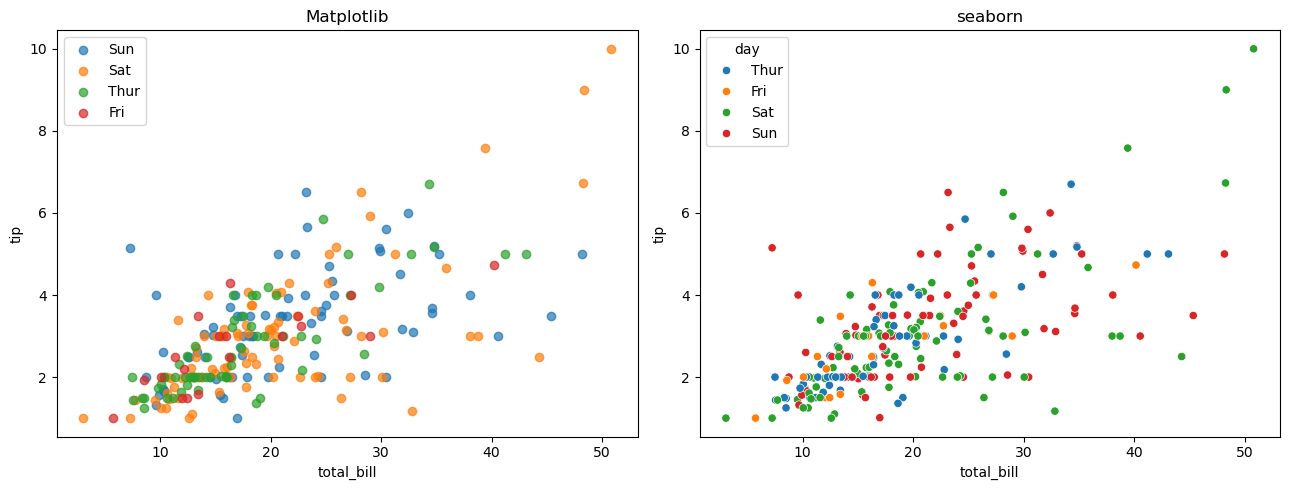

In [9]:
# Same plot — matplotlib vs seaborn
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matplotlib: loop over days, call scatter for each
ax = axes[0]
for day in tips['day'].unique():
    sub = tips[tips['day'] == day]
    ax.scatter(sub['total_bill'], sub['tip'], label=day, alpha=0.7)
ax.set_xlabel('total_bill')
ax.set_ylabel('tip')
ax.set_title("Matplotlib")
ax.legend()

# seaborn: one call, hue does the grouping
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='day', ax=axes[1])
axes[1].set_title("seaborn")

plt.tight_layout()
plt.show()

**Reading the code:**

The two panels show the same chart written two ways.

- **Matplotlib version** — manual category loop. `tips['day'].unique()` returns the four day labels (`Thur`, `Fri`, `Sat`, `Sun`). For each one, slice the DataFrame to just those rows and call `scatter` separately. Three calls + a legend.
- **seaborn version** — a single `sns.scatterplot(...)` call. The `hue='day'` argument tells seaborn to color points by that column. seaborn handles the loop internally and adds the legend automatically.

`ax=axes[1]` is how you tell a seaborn function to draw onto an existing matplotlib axes. Without it, seaborn would create its own figure. This is the bridge: seaborn calls return matplotlib objects, so you can mix and match — use a seaborn function for the core plot, then reach for `ax.set_title`, `ax.set_ylim`, `ax.spines[...]`, and so on for final tweaks.

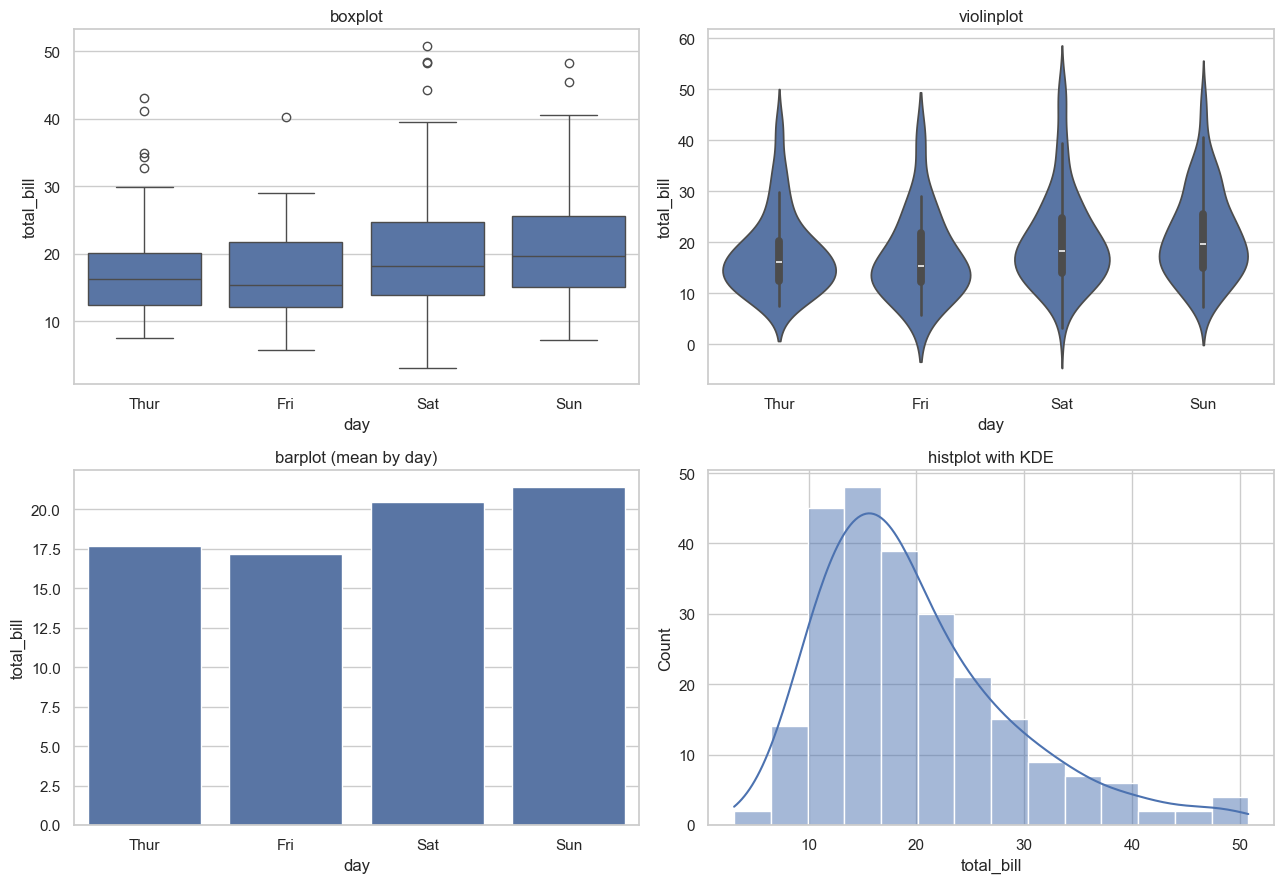

In [10]:
# seaborn's signature statistical plots
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Box plot by category
sns.boxplot(data=tips, x='day', y='total_bill', ax=axes[0, 0])
axes[0, 0].set_title("boxplot")

# Violin plot — box plot + density estimate
sns.violinplot(data=tips, x='day', y='total_bill', ax=axes[0, 1])
axes[0, 1].set_title("violinplot")

# Bar plot — automatic mean aggregation per category
sns.barplot(data=tips, x='day', y='total_bill', ax=axes[1, 0], errorbar=None)
axes[1, 0].set_title("barplot (mean by day)")

# Histogram with KDE overlay
sns.histplot(data=tips, x='total_bill', kde=True, ax=axes[1, 1])
axes[1, 1].set_title("histplot with KDE")

plt.tight_layout()
plt.show()

sns.set_theme()  # reset to default theme

**Reading the code:**

- `sns.set_theme(style="whitegrid")` switches the global theme: white background with light gridlines. The four `seaborn` calls below pick this up automatically. At the end of the cell, `sns.set_theme()` with no arguments restores the default theme so the rest of the notebook isn't affected.
- `sns.boxplot(data=tips, x='day', y='total_bill', ax=...)` — note the keyword-argument style. seaborn functions all take `data=` (the DataFrame) and column names as strings for the axes. This means the same call shape works for every plot type; once you know one, you know them all.
- `sns.barplot(..., errorbar=None)` is doing more than it looks. seaborn's `barplot` automatically aggregates: it computes the mean of `total_bill` for each `day` and plots bars at those means. The `errorbar=None` argument suppresses the default 95% confidence interval whiskers — useful when you just want the bar heights without statistical decoration.
- `sns.histplot(..., kde=True)` draws a histogram with an extra smooth curve overlaid — the kernel density estimate (KDE), which is a continuous estimate of the same distribution. The combination is more informative than either alone.

### When to reach for seaborn vs matplotlib

| Situation | Tool |
|---|---|
| Quick statistical plots from a DataFrame | seaborn |
| Plots that need `hue=` (color by category) | seaborn |
| Box, violin, regression, pair plots | seaborn |
| Custom non-uniform layouts | matplotlib |
| Fine-tuned styling and annotations | matplotlib |
| ML-specific (confusion matrix, ROC curve) | matplotlib (or sklearn's plotting helpers) |

## A Complete Visualization Project

Putting everything together: a multi-panel dashboard of a year of fake e-commerce data. The figure uses GridSpec for a non-uniform layout, includes a line chart with a rolling average, a sorted horizontal bar chart, a histogram with a reference line, a stacked monthly bar, and a heatmap.

This is also a useful template — most dashboards you build in real work will have this same structure: a hero chart (the big one at the top) and a row or two of supporting context.

In [11]:
# Generate fake e-commerce data
np.random.seed(0)
n_days = 365

df = pd.DataFrame({
    'date':    pd.date_range('2024-01-01', periods=n_days),
    'orders':  np.random.poisson(50, n_days) +
               np.sin(np.arange(n_days) * 2 * np.pi / 365) * 20,
    'revenue': np.random.poisson(5000, n_days) +
               np.sin(np.arange(n_days) * 2 * np.pi / 365) * 2000,
})
df['region']   = np.random.choice(['North', 'South', 'East', 'West'], n_days)
df['category'] = np.random.choice(['Electronics', 'Clothing', 'Books', 'Home'], n_days)

print(df.head())
print(f"\nShape: {df.shape}")

        date     orders      revenue region     category
0 2024-01-01  51.000000  5025.000000   East         Home
1 2024-01-02  52.344267  5124.426712   West  Electronics
2 2024-01-03  48.688432  5048.843223  North        Books
3 2024-01-04  50.032393  5173.239334   West        Books
4 2024-01-05  70.376049  5073.604854   West  Electronics

Shape: (365, 5)


The dataset has one row per day of 2024 (365 days) plus a few categorical columns. The `np.sin(...)` term layered onto orders and revenue introduces a seasonal pattern so the rolling average will reveal something interesting later, not just noise.

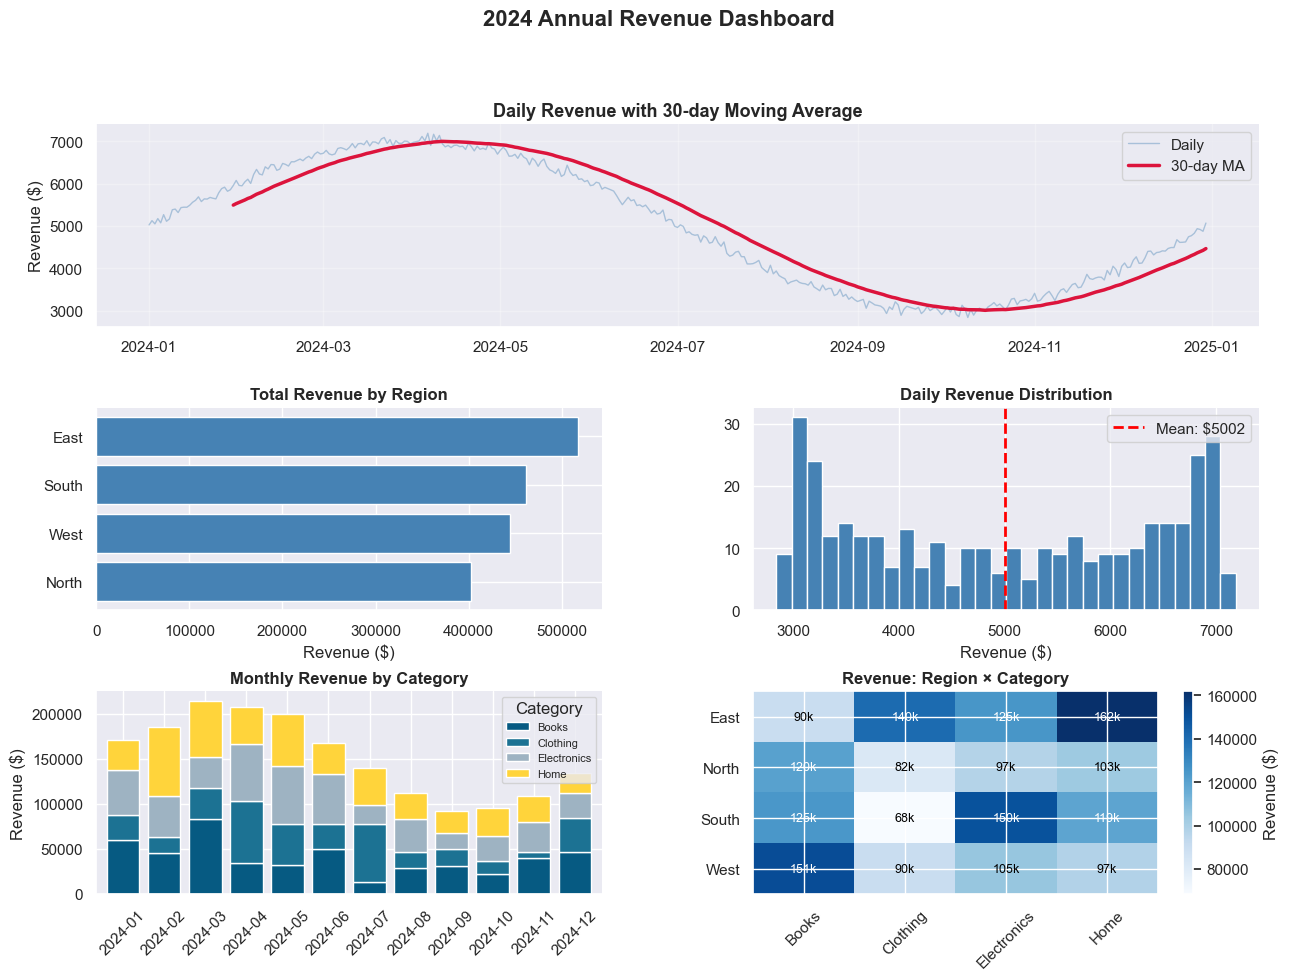

In [12]:
# Build a 5-panel dashboard
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(15, 10))
gs = GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.3)

# Panel 1: Daily revenue trend (full width)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df['date'], df['revenue'], color='steelblue', alpha=0.4, linewidth=1, label='Daily')
ax1.plot(df['date'], df['revenue'].rolling(30).mean(),
         color='crimson', linewidth=2.5, label='30-day MA')
ax1.set_title("Daily Revenue with 30-day Moving Average", fontsize=13, fontweight='bold')
ax1.set_ylabel("Revenue ($)")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Panel 2: Revenue by region (sorted horizontal bars)
ax2 = fig.add_subplot(gs[1, 0])
region_revenue = df.groupby('region')['revenue'].sum().sort_values()
ax2.barh(region_revenue.index, region_revenue.values, color='steelblue')
ax2.set_title("Total Revenue by Region", fontsize=12, fontweight='bold')
ax2.set_xlabel("Revenue ($)")
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Panel 3: Revenue distribution (histogram + mean line)
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(df['revenue'], bins=30, color='steelblue', edgecolor='white')
ax3.axvline(df['revenue'].mean(), color='red', linestyle='--', linewidth=2,
            label=f"Mean: ${df['revenue'].mean():.0f}")
ax3.set_title("Daily Revenue Distribution", fontsize=12, fontweight='bold')
ax3.set_xlabel("Revenue ($)")
ax3.legend()
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# Panel 4: Revenue by category over time (stacked monthly bars)
ax4 = fig.add_subplot(gs[2, 0])
monthly = df.groupby([df['date'].dt.to_period('M'), 'category'])['revenue'].sum().unstack()
monthly.plot(kind='bar', stacked=True, ax=ax4,
             color=['#065A82', '#1C7293', '#9EB3C2', '#FFD43B'], width=0.8)
ax4.set_title("Monthly Revenue by Category", fontsize=12, fontweight='bold')
ax4.set_xlabel("")
ax4.set_ylabel("Revenue ($)")
ax4.set_xticklabels([str(m) for m in monthly.index], rotation=45)
ax4.legend(title='Category', fontsize=8)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# Panel 5: Region × Category heatmap
ax5 = fig.add_subplot(gs[2, 1])
heatmap_data = df.pivot_table(index='region', columns='category', values='revenue', aggfunc='sum')
im = ax5.imshow(heatmap_data.values, cmap='Blues', aspect='auto')
ax5.set_xticks(range(len(heatmap_data.columns)))
ax5.set_xticklabels(heatmap_data.columns, rotation=45)
ax5.set_yticks(range(len(heatmap_data.index)))
ax5.set_yticklabels(heatmap_data.index)
ax5.set_title("Revenue: Region × Category", fontsize=12, fontweight='bold')
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        val = heatmap_data.values[i, j]
        ax5.text(j, i, f'{val/1000:.0f}k', ha='center', va='center',
                 color='white' if val > heatmap_data.values.mean() else 'black', fontsize=9)
fig.colorbar(im, ax=ax5, label='Revenue ($)')

fig.suptitle("2024 Annual Revenue Dashboard", fontsize=16, fontweight='bold', y=0.995)
plt.show()

**Reading the dashboard code:**

This cell combines almost everything from the four matplotlib notebooks. Walking through panel by panel:

- **The grid** — `GridSpec(3, 2, ...)` with `hspace=0.4, wspace=0.3` gives 3 rows × 2 columns with generous spacing so titles in different panels don't crash into each other. The hero chart claims the entire top row via `gs[0, :]`.
- **Panel 1 (revenue trend)** — two `plot` calls on the same axes. The daily line is at `alpha=0.4` so it reads as faint background; the 30-day rolling average in solid crimson is the main story. `df['revenue'].rolling(30).mean()` is pandas' rolling-window machinery — the seasonal pattern from the sine-injected data becomes obvious in the smooth red curve.
- **Panel 2 (revenue by region)** — `groupby('region')['revenue'].sum().sort_values()` aggregates and sorts. Plotting the sorted Series as horizontal bars means the longest bar ends up on top, which is the standard reading order for bar charts of magnitudes.
- **Panel 3 (revenue distribution)** — a histogram with `axvline` showing the mean. The vertical line is the reference: the reader sees the distribution and knows immediately where the average sits.
- **Panel 4 (monthly stacked bars)** — `pivot_table` (via `groupby + unstack`) reshapes the data into a months × category matrix, then `.plot(kind='bar', stacked=True)` is pandas' shortcut for stacked bars. The 30-day-trend story from Panel 1 reappears in a different form: months with larger total bars are the high-revenue months.
- **Panel 5 (region × category heatmap)** — `df.pivot_table(...)` reshapes again, then the standard imshow + annotation pattern from the heatmap section. Using `val/1000:.0f}k` keeps the cell labels short ("125k" instead of "125000").
- **The suptitle** — `fig.suptitle(...)` is the figure-level title (above all the panels), as opposed to `ax.set_title` (one panel's title). `y=0.995` nudges it just below the top edge of the figure so it doesn't get clipped.

## Practice Exercises

### Exercise 1
Use GridSpec to create a layout with:
- A large plot spanning the entire left column (full height)
- Three smaller plots stacked on the right

Fill each with a different chart type.

### Exercise 2
Create a twin-axis plot showing twelve months of data: temperature (line on the left y-axis) and ice cream sales (bars on the right y-axis).

### Exercise 3
Generate a 6×6 random matrix. Create a heatmap with each cell annotated with its numeric value, using the `viridis` colormap.

### Exercise 4
Simulate a confusion matrix for a 3-class classifier (make up the numbers). Plot it with proper labels and the accuracy displayed below.

### Exercise 5 (challenge — capstone)
Pick any dataset you'd like to analyze (or use the e-commerce data above). Build a 2×2 dashboard with:
- A time series chart
- A bar chart
- A distribution plot (histogram)
- A heatmap

Apply consistent styling — same color family, hidden top/right spines, bolded titles.

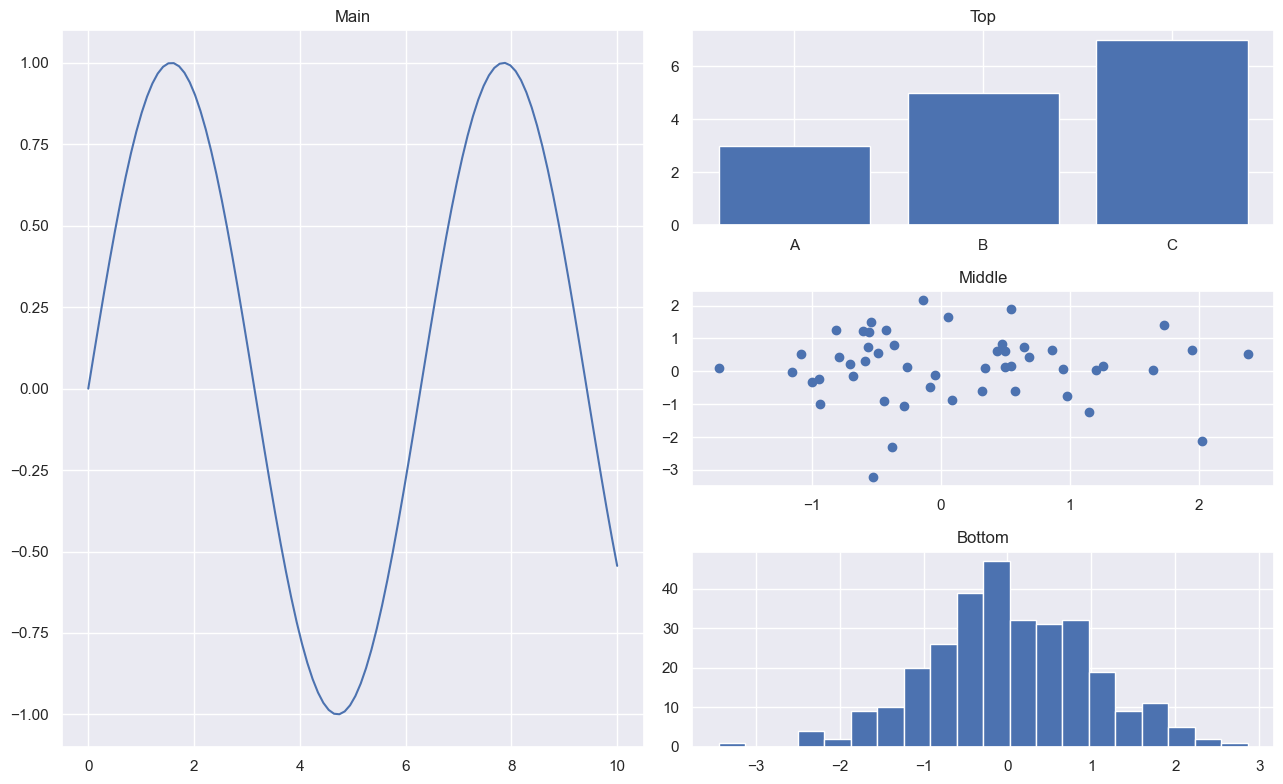

In [13]:
# Exercise 1
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(13, 8))
gs = GridSpec(3, 2, figure=fig)

ax_main = fig.add_subplot(gs[:, 0])
ax_top  = fig.add_subplot(gs[0, 1])
ax_mid  = fig.add_subplot(gs[1, 1])
ax_bot  = fig.add_subplot(gs[2, 1])

x = np.linspace(0, 10, 100)
ax_main.plot(x, np.sin(x))
ax_main.set_title("Main")

ax_top.bar(['A', 'B', 'C'], [3, 5, 7])
ax_top.set_title("Top")

ax_mid.scatter(np.random.randn(50), np.random.randn(50))
ax_mid.set_title("Middle")

ax_bot.hist(np.random.randn(300), bins=20)
ax_bot.set_title("Bottom")

plt.tight_layout()
plt.show()

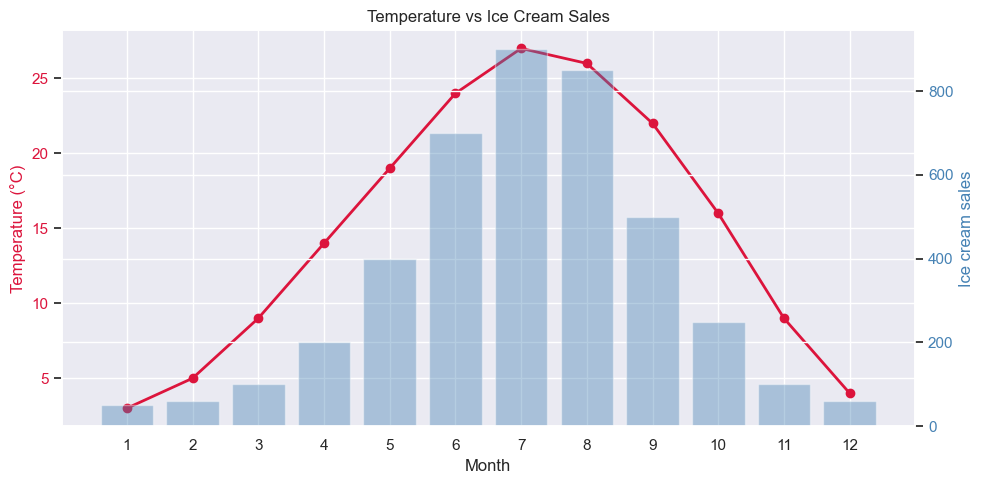

In [14]:
# Exercise 2
months = np.arange(1, 13)
temp = [3, 5, 9, 14, 19, 24, 27, 26, 22, 16, 9, 4]
ice_cream = [50, 60, 100, 200, 400, 700, 900, 850, 500, 250, 100, 60]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(months, temp, color='crimson', marker='o', linewidth=2, label='Temp')
ax1.set_xlabel("Month")
ax1.set_ylabel("Temperature (°C)", color='crimson')
ax1.tick_params(axis='y', labelcolor='crimson')

ax2 = ax1.twinx()
ax2.bar(months, ice_cream, color='steelblue', alpha=0.4, label='Ice cream sales')
ax2.set_ylabel("Ice cream sales", color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

ax1.set_xticks(months)
ax1.set_title("Temperature vs Ice Cream Sales")
plt.tight_layout()
plt.show()

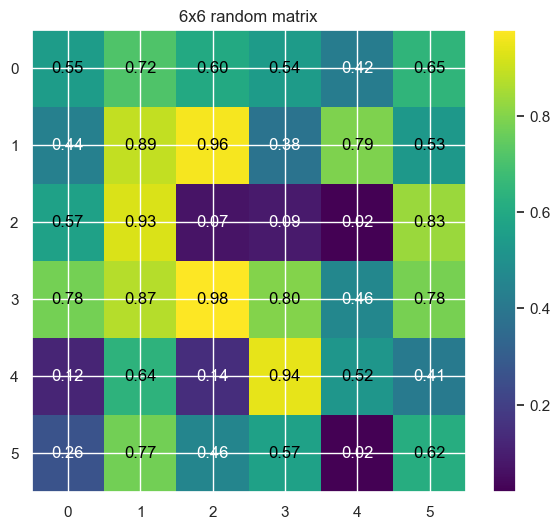

In [15]:
# Exercise 3
np.random.seed(0)
m = np.random.rand(6, 6)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(m, cmap='viridis', aspect='auto')
fig.colorbar(im, ax=ax)

for i in range(6):
    for j in range(6):
        ax.text(j, i, f'{m[i, j]:.2f}', ha='center', va='center',
                color='white' if m[i, j] < 0.5 else 'black')

ax.set_title("6x6 random matrix")
plt.show()

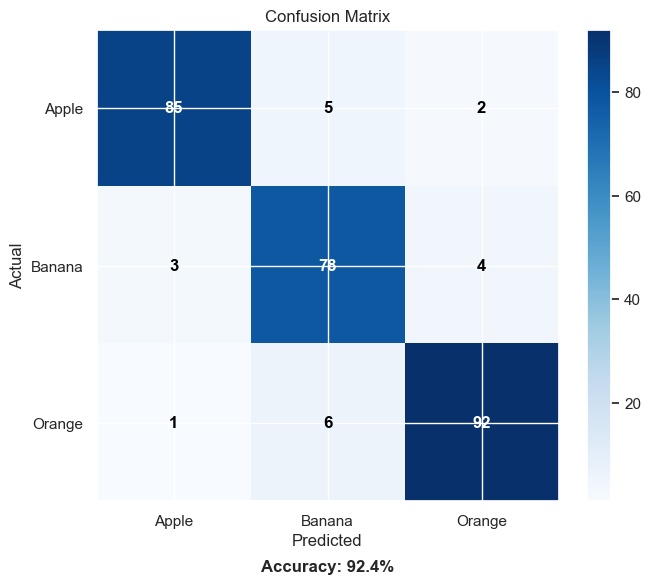

In [16]:
# Exercise 4
classes = ['Apple', 'Banana', 'Orange']
cm = np.array([
    [85,  5,  2],
    [ 3, 78,  4],
    [ 1,  6, 92],
])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues', aspect='auto')
fig.colorbar(im, ax=ax)

ax.set_xticks(range(3))
ax.set_xticklabels(classes)
ax.set_yticks(range(3))
ax.set_yticklabels(classes)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")

thresh = cm.max() / 2
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black', fontweight='bold')

acc = np.trace(cm) / cm.sum()
ax.text(0.5, -0.15, f'Accuracy: {acc*100:.1f}%',
        transform=ax.transAxes, ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

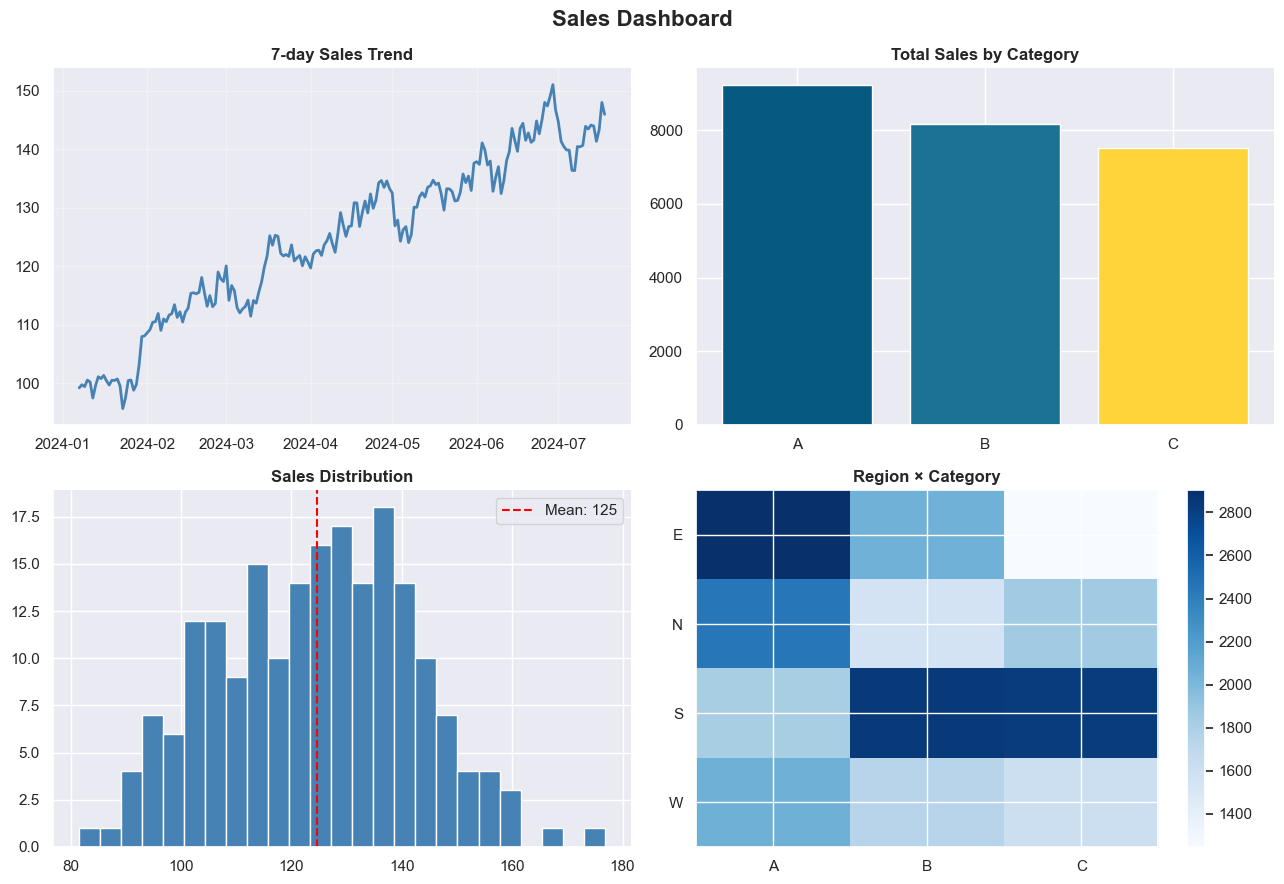

In [17]:
# Exercise 5 — Mini dashboard
np.random.seed(42)
n = 200

df = pd.DataFrame({
    'date':     pd.date_range('2024-01-01', periods=n),
    'sales':    np.random.poisson(100, n) + np.linspace(0, 50, n),
    'category': np.random.choice(['A', 'B', 'C'], n),
    'region':   np.random.choice(['N', 'S', 'E', 'W'], n),
})

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Time series
axes[0, 0].plot(df['date'], df['sales'].rolling(7).mean(), color='steelblue', linewidth=2)
axes[0, 0].set_title("7-day Sales Trend", fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].spines['top'].set_visible(False); axes[0, 0].spines['right'].set_visible(False)

# Bar chart
cat_sales = df.groupby('category')['sales'].sum()
axes[0, 1].bar(cat_sales.index, cat_sales.values, color=['#065A82', '#1C7293', '#FFD43B'])
axes[0, 1].set_title("Total Sales by Category", fontweight='bold')
axes[0, 1].spines['top'].set_visible(False); axes[0, 1].spines['right'].set_visible(False)

# Histogram
axes[1, 0].hist(df['sales'], bins=25, color='steelblue', edgecolor='white')
axes[1, 0].axvline(df['sales'].mean(), color='red', linestyle='--',
                   label=f"Mean: {df['sales'].mean():.0f}")
axes[1, 0].set_title("Sales Distribution", fontweight='bold')
axes[1, 0].legend()
axes[1, 0].spines['top'].set_visible(False); axes[1, 0].spines['right'].set_visible(False)

# Heatmap
heat = df.pivot_table(index='region', columns='category', values='sales', aggfunc='sum')
im = axes[1, 1].imshow(heat.values, cmap='Blues', aspect='auto')
axes[1, 1].set_xticks(range(len(heat.columns)))
axes[1, 1].set_xticklabels(heat.columns)
axes[1, 1].set_yticks(range(len(heat.index)))
axes[1, 1].set_yticklabels(heat.index)
axes[1, 1].set_title("Region × Category", fontweight='bold')
fig.colorbar(im, ax=axes[1, 1])

fig.suptitle("Sales Dashboard", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary

This notebook covered the advanced matplotlib tools that make the difference between a quick exploratory chart and a finished figure ready to share:

- **GridSpec** for layouts that aren't a uniform grid — the hero-and-supporting-panels pattern most dashboards use
- **Twin axes** (`ax.twinx()`) for plotting two variables with different scales on the same chart, with matched color cues so the reader knows which axis is which
- **Heatmaps** via `imshow` — for activity matrices (use a sequential colormap), correlation matrices (use a diverging colormap with `vmin=-1, vmax=1`), and confusion matrices (use `'Blues'` and label the axes Actual vs Predicted)
- **Publication-quality saves** with `dpi=300`, `bbox_inches='tight'`, and `facecolor='white'`, plus the visual habits — thicker lines, hidden top/right spines, padded titles — that hold up at scale
- **seaborn** as the higher-level layer for quick statistical plots from a DataFrame, with `hue=` as the killer feature
- **A full dashboard pattern** — GridSpec layout, a hero chart, supporting context in smaller panels, consistent styling across all of them

You now have the complete matplotlib + seaborn toolkit. The next steps in the data stack are scikit-learn for modeling and either PyTorch or TensorFlow for deep learning — both of which return arrays you can feed straight back into the visualization code from this notebook.